# Implied Correlation Signal

This notebook will look at using implied correlation within trend following. 

# Packages & Paths

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
curr_path = os.getcwd()
research_path = os.path.abspath(os.path.join(curr_path, ".."))
repo_path     = os.path.abspath(os.path.join(research_path, ".."))
data_path     = os.path.join(repo_path, "data")
fut_path      = os.path.join(data_path, "FuturesData")
misc_path     = os.path.join(data_path, "MiscData")

In [3]:
tool_path = os.path.join(repo_path, "src", "Tools")
sys.path.append(tool_path)

from SignalTools import SignalAnalysis

# Getting Data

In [4]:
fut_px_path = os.path.join(fut_path, "PrepFuturesPX.parquet")
ic_px_path  = os.path.join(misc_path, "CleanedImpliedRealCorrelation.parquet")
ticker_path = os.path.join(misc_path, "ImpliedCorrelationTickerGuide.xlsx")

df_fut = (pd
    .read_parquet(path = fut_px_path, engine = "pyarrow"))

df_corr = (pd
    .read_parquet(path = ic_px_path, engine = "pyarrow")
    .loc[lambda x: x.file == "ImpliedCorr"]
    .drop(columns = ["file", "clean_val"])
    .rename(columns = {
        "variable": "eq_ticker",
        "Date"    : "date"})
    .drop_duplicates())

df_corr_fut_guide = (pd
    .read_excel(io = ticker_path, sheet_name = "TickerGuide")
    .rename(columns = {
        "Equity Index": "equity",
        "Future"      : "future"})
    .assign(
        equity = lambda x: x.equity.str.split(" ").str[0],
        future = lambda x: x.future.str.replace(" 1", "1").str.replace(" ", "_").str.lower())
    .dropna()
    .rename(columns = {"future": "ticker"})
    .loc[lambda x: x.ticker == "es1_index"])

In [5]:
path  = os.path.join(data_path, "Signals", "DaoNguyenDerembleLemperiereBouchaudPotters.parquet")
df_px = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .merge(right = df_corr_fut_guide, how = "inner", on = ["ticker"])
    [["date", "ticker", "px", "px_diff", "px_rtn"]])

In [87]:
df_scaler = (df_corr
    .assign(date = lambda x: pd.to_datetime(x.date).dt.date)
    .set_index("date")
    .groupby(["eq_ticker", "window"])
    #.apply(lambda x: x.value)
    .apply(lambda x: -(x.sort_index().value + 1).diff())
    .to_frame(name = "scaler")
    .reset_index())

In [88]:
df_combined = (df_corr_fut_guide
    .merge(right = df_px, how = "inner", on = ["ticker"])
    .rename(columns = {"equity": "eq_ticker"})
    .merge(right = df_scaler, how = "inner", on = ["date", "eq_ticker"])
    .dropna())

In [89]:
df_corr_scaled_rtn = (df_combined
    .assign(adj_val = lambda x: x.scaler * x.px_diff)
    [["ticker", "date", "px_diff", "window", "adj_val"]])

In [90]:
df_signal = (df_corr_scaled_rtn
    .pivot(index = ["date", "ticker", "px_diff"], columns = "window", values = "adj_val")
    .reset_index()
    .melt(id_vars = ["date", "ticker"])
    .assign(name = lambda x: x.ticker + "-" + x.window)
    .pivot(index = "date", columns = "name", values = "value")
    .apply(lambda x: x / x.ewm(span = 10, adjust = False).std())
    .apply(lambda x: x.ewm(span = 100, adjust = False).mean())
    .shift()
    .reset_index()
    .melt(id_vars = "date", value_name = "signal")
    .assign(
        ticker = lambda x: x.name.str.split("-").str[0],
        window = lambda x: x.name.str.split("-").str[1])
    .drop(columns = ["name"])
    .replace({"px_diff": "Raw Signal"}))

In [91]:
(df_signal
    .pivot(index = "date", columns = "window", values = "signal")
    .corr())

window,OneMonth,OneYear,Raw Signal,SixMonth,ThreeMonth
window,,,,,
OneMonth,1.000000,0.778938,-0.205860,0.877886,0.927736
OneYear,0.778938,1.000000,-0.206297,0.922882,0.877771
Raw Signal,-0.205860,-0.206297,1.000000,-0.260156,-0.215451
SixMonth,0.877886,0.922882,-0.260156,1.000000,0.951446
ThreeMonth,0.927736,0.877771,-0.215451,0.951446,1.000000


In [92]:
df_signal_rtn = (df_signal
    .merge(right = df_px, how = "inner", on = ["date", "ticker"])
    .assign(
        name       = lambda x: x.ticker + "-" + x.window,
        signal_rtn = lambda x: x.signal * x.px_rtn))

In [93]:
df_vol_rtn = (df_signal_rtn
    .pivot(index = "date", columns = "window", values = "signal_rtn")
    .apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252))))
    .apply(lambda x: np.where(np.abs(x) > 0.1, np.nan, x)))

<Axes: xlabel='date'>

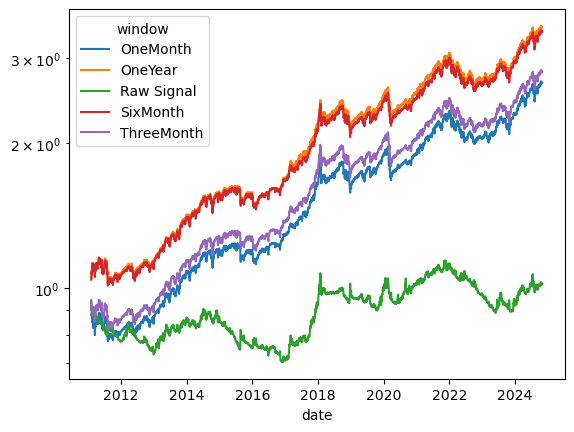

In [94]:
(df_vol_rtn
    .apply(lambda x: np.cumprod(1 + x))
    .plot(logy = True))

In [95]:
df_cuml = (df_vol_rtn
    .apply(lambda x: x.rolling(window = 50).sum())
    .reset_index()
    .melt(id_vars = "date", value_name = "cuml_pnl")
    .dropna())

In [96]:
df_combined = (df_signal
    .merge(right = df_cuml, how = "inner", on = ["date", "window"]))

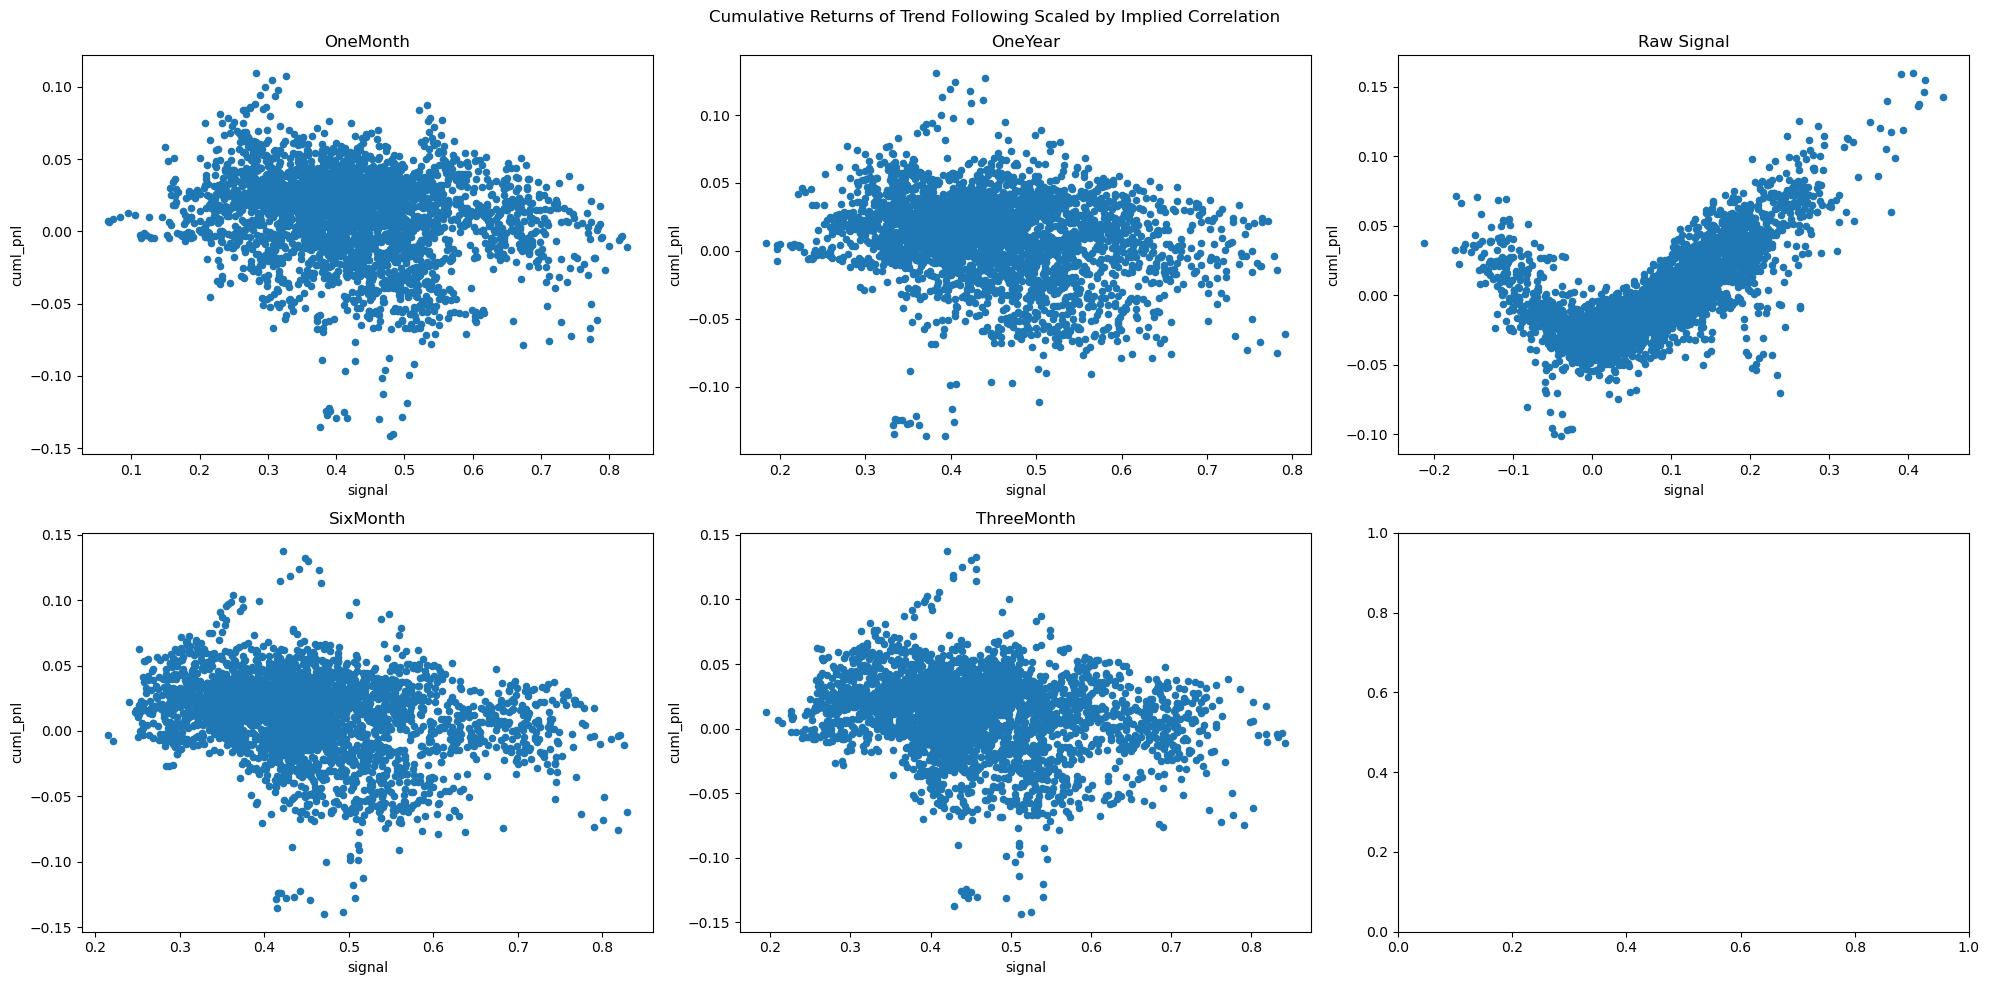

In [107]:
windows = df_combined.window.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 3, nrows = 2, figsize = (20,10))

for window, ax in zip(windows, axes.flatten()):

    (df_combined
        .loc[lambda x: x.window == window]
        .assign(year = lambda x: pd.to_datetime(x.date).dt.year)
        .loc[lambda x: x.year != x.year.min()]
        .plot(
            ax   = ax,
            kind = "scatter", x = "signal", y = "cuml_pnl",
            title = window))

fig.suptitle("Cumulative Returns of Trend Following Scaled by Implied Correlation")
plt.tight_layout()

In [106]:
(df_vol_rtn
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .to_frame(name = "Sharpe")
    .sort_values("Sharpe")
    .T)

window,Raw Signal,OneMonth,ThreeMonth,SixMonth,OneYear
Sharpe,0.064529,0.746087,0.792329,0.937833,0.951654
